## Imports

In [8]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

d:\Tisya\projects\AYUSH\venv\Scripts\python.exe


## Load the data

In [9]:
train = pd.read_csv(
    "../data/processed/FD001/train_FD001_clean.csv"
)

print("Shape:", train.shape)
display(train.head())

Shape: (20631, 19)


,unit,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


## Engine lifetime distribution

In [10]:
engine_lifetimes = (
    train.groupby("unit")["cycle"]
    .max()
)

display(engine_lifetimes.head(10))

unit
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64

In [11]:
print("Number of engines:", engine_lifetimes.shape[0])

display(engine_lifetimes.describe())

Number of engines: 100


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

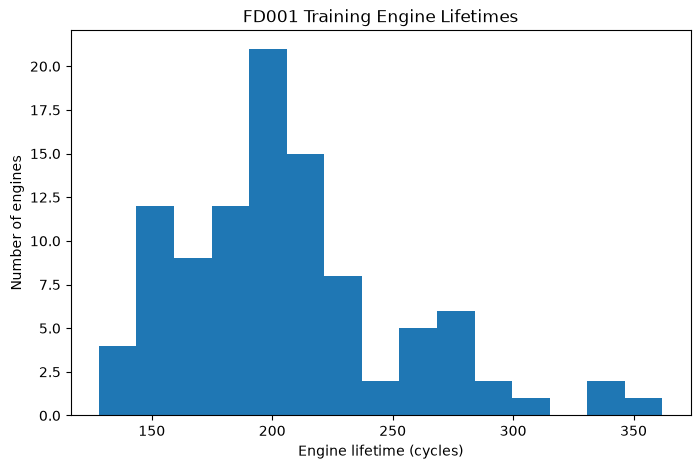

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    engine_lifetimes,
    bins=15
)

plt.xlabel("Engine lifetime (cycles)")
plt.ylabel("Number of engines")
plt.title("FD001 Training Engine Lifetimes")

plt.show()

## Operating-setting exploration

In [13]:
op_settings = [
    "op_setting_1",
    "op_setting_2"
]

display(
    train[op_settings].describe().T
)

,count,mean,std,min,25%,50%,75%,max
op_setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
op_setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006


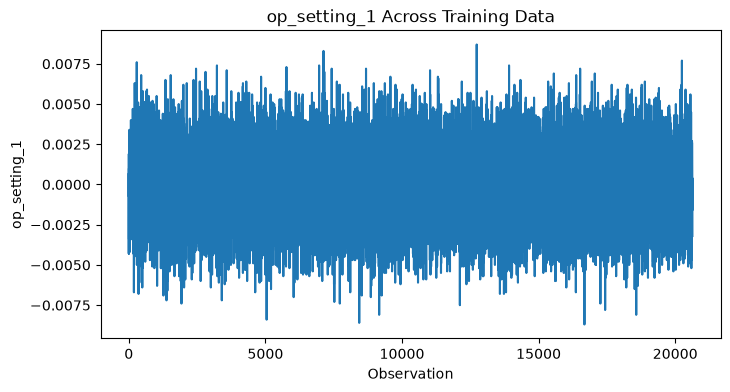

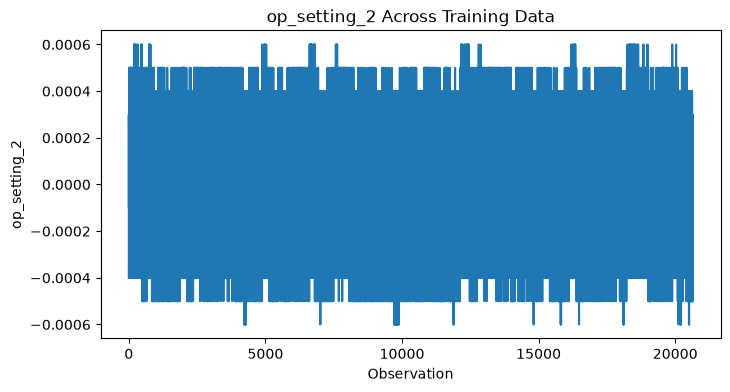

In [14]:
for column in op_settings:
    plt.figure(figsize=(8, 4))

    plt.plot(train[column])

    plt.xlabel("Observation")
    plt.ylabel(column)
    plt.title(f"{column} Across Training Data")

    plt.show()

## Sensor variability

In [15]:
sensor_columns = [
    column
    for column in train.columns
    if column.startswith("sensor_")
]

print("Number of sensors:", len(sensor_columns))
print(sensor_columns)

Number of sensors: 15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [16]:
sensor_std = (
    train[sensor_columns]
    .std()
    .sort_values()
)

display(sensor_std)

sensor_6      0.001389
sensor_15     0.037505
sensor_8      0.070985
sensor_13     0.071919
sensor_21     0.108251
sensor_20     0.180746
sensor_11     0.267087
sensor_2      0.500053
sensor_12     0.737553
sensor_7      0.885092
sensor_17     1.548763
sensor_3      6.131150
sensor_4      9.000605
sensor_14    19.076176
sensor_9     22.082880
dtype: float64

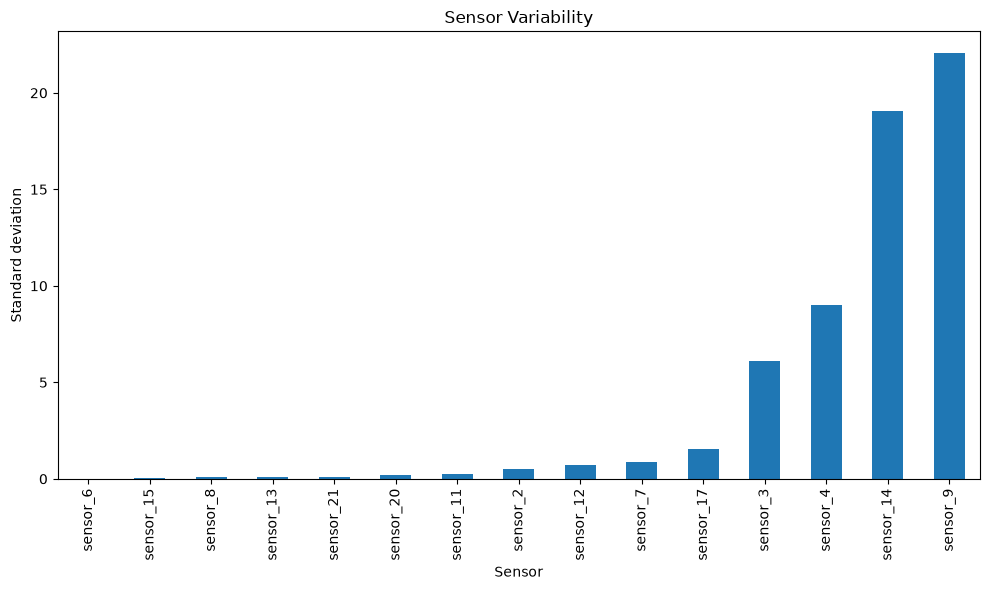

In [17]:
plt.figure(figsize=(10, 6))

sensor_std.plot(kind="bar")

plt.xlabel("Sensor")
plt.ylabel("Standard deviation")
plt.title("Sensor Variability")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Sensor relationship with cycle

In [18]:
sensor_cycle_corr = (
    train[sensor_columns + ["cycle"]]
    .corr()["cycle"]
    .drop("cycle")
    .sort_values()
)

display(sensor_cycle_corr)

sensor_12   -0.611354
sensor_7    -0.595914
sensor_21   -0.585923
sensor_20   -0.583597
sensor_6     0.105980
sensor_14    0.370324
sensor_9     0.443999
sensor_8     0.475977
sensor_13    0.477523
sensor_3     0.543947
sensor_2     0.549898
sensor_17    0.566995
sensor_15    0.588676
sensor_4     0.624577
sensor_11    0.634385
Name: cycle, dtype: float64

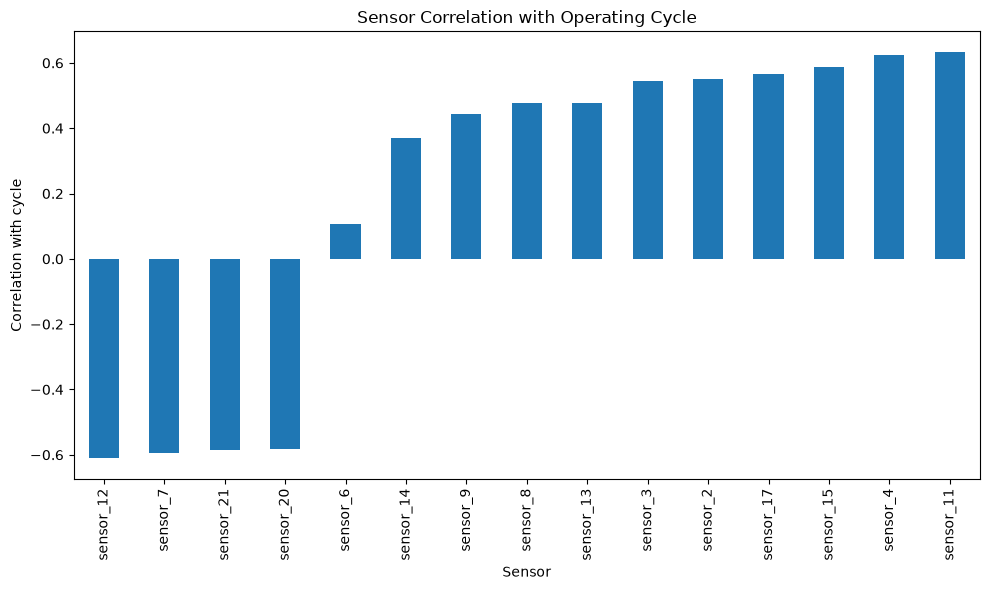

In [19]:
plt.figure(figsize=(10, 6))

sensor_cycle_corr.plot(kind="bar")

plt.xlabel("Sensor")
plt.ylabel("Correlation with cycle")
plt.title("Sensor Correlation with Operating Cycle")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Individual degradation capacity

In [20]:
selected_sensors = [
    "sensor_2",
    "sensor_4",
    "sensor_7",
    "sensor_9",
    "sensor_11",
    "sensor_14"
]

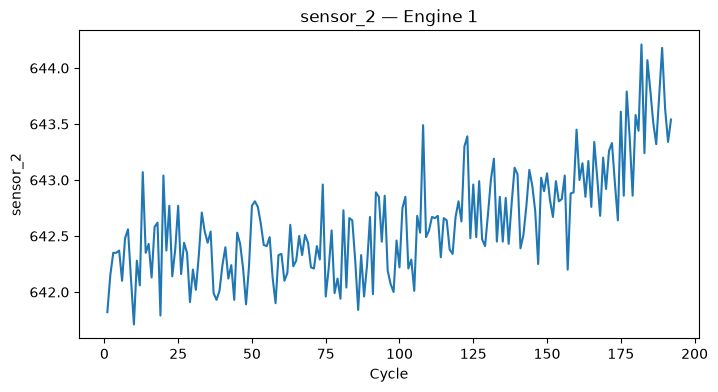

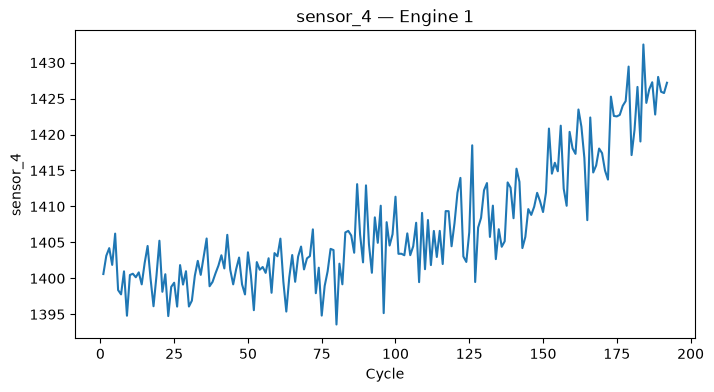

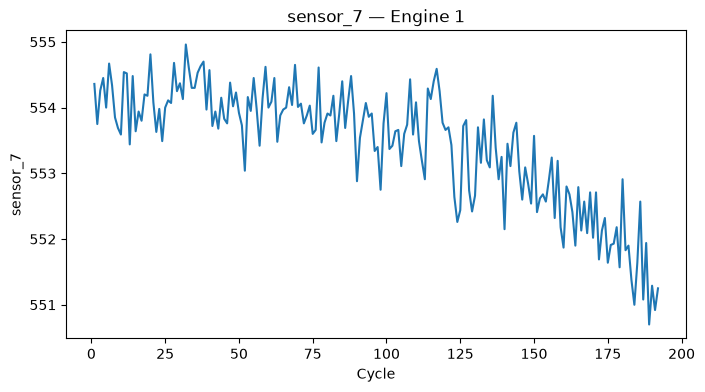

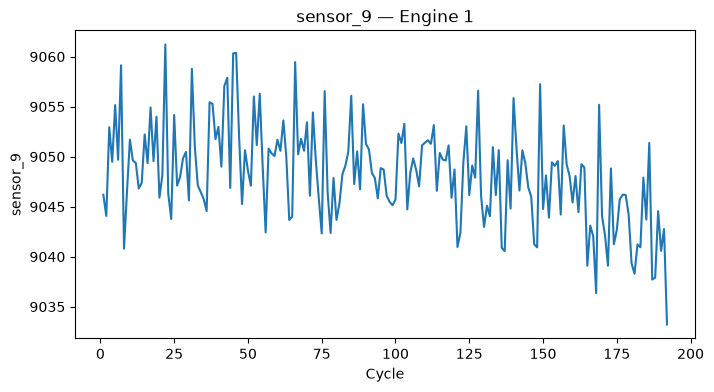

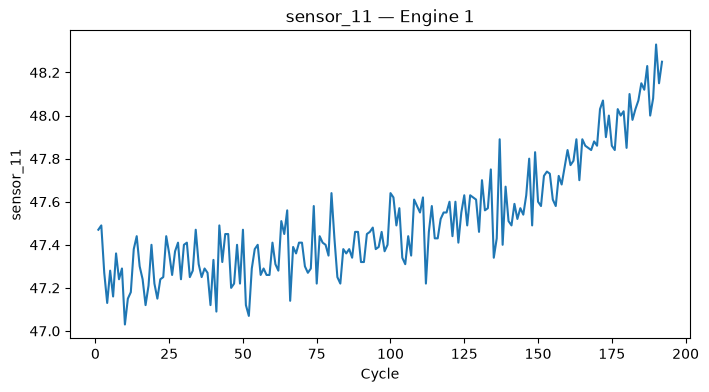

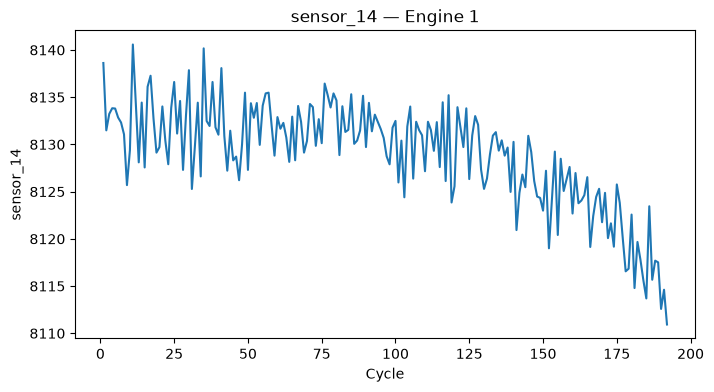

In [21]:
engine_id = 1

engine_data = train[
    train["unit"] == engine_id
]

for sensor in selected_sensors:

    plt.figure(figsize=(8, 4))

    plt.plot(
        engine_data["cycle"],
        engine_data[sensor]
    )

    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.title(f"{sensor} — Engine {engine_id}")

    plt.show()

## Comparison between engines

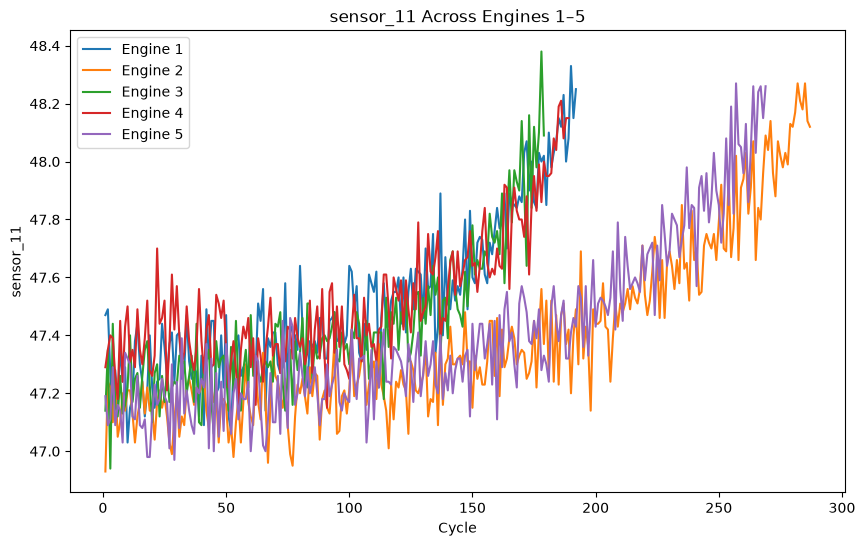

In [22]:
sensor = "sensor_11"

plt.figure(figsize=(10, 6))

for engine_id in [1, 2, 3, 4, 5]:

    engine_data = train[
        train["unit"] == engine_id
    ]

    plt.plot(
        engine_data["cycle"],
        engine_data[sensor],
        label=f"Engine {engine_id}"
    )

plt.xlabel("Cycle")
plt.ylabel(sensor)
plt.title(f"{sensor} Across Engines 1–5")
plt.legend()

plt.show()

## Correlation

In [23]:
correlation = train[
    ["cycle"] + sensor_columns
].corr()

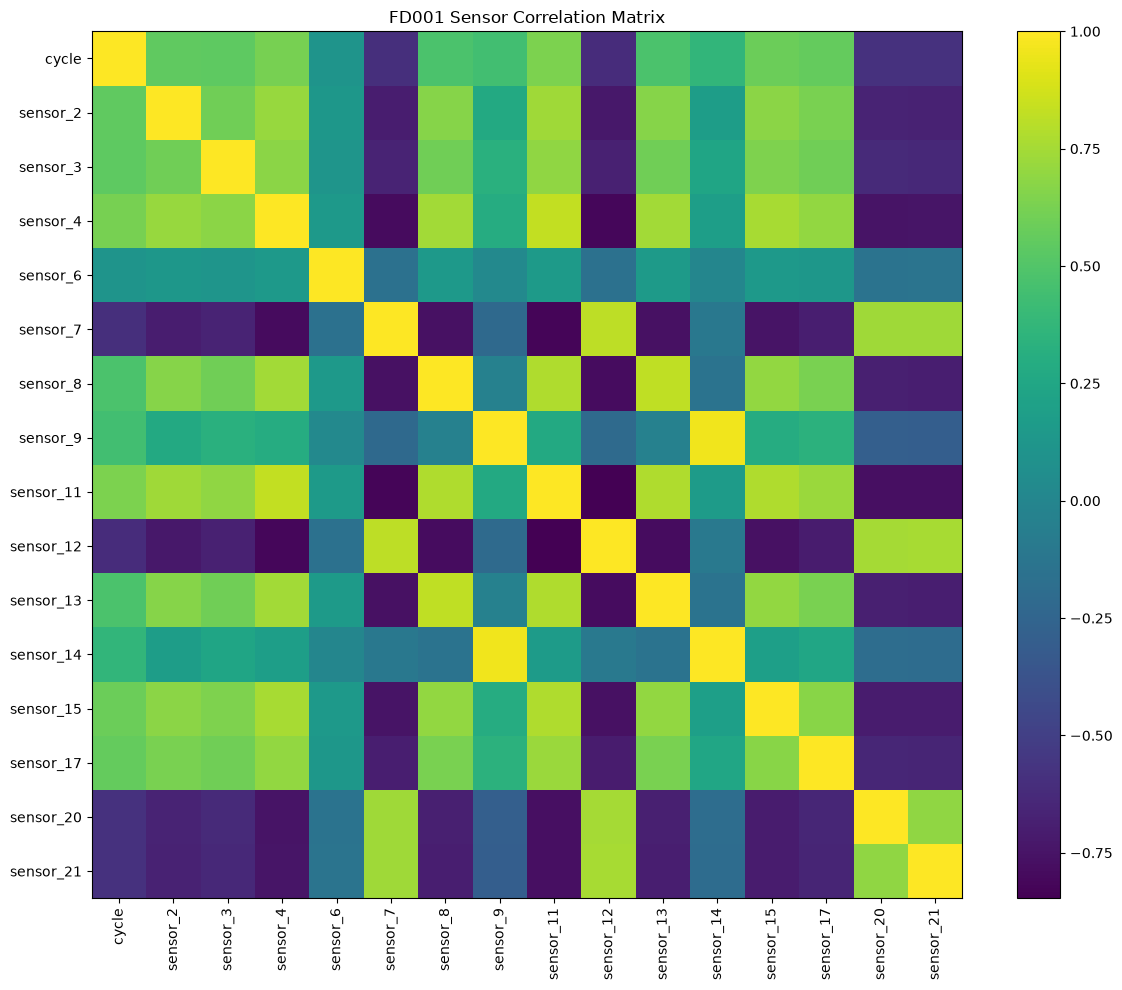

In [24]:
plt.figure(figsize=(12, 10))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("FD001 Sensor Correlation Matrix")

plt.tight_layout()
plt.show()

### EDA Conclusions

- The FD001 training set contains 100 engines with substantially different lifetimes, ranging from 128 to 362 cycles.
- The mean engine lifetime is approximately 206 cycles, with a median of 199 cycles.
- The two remaining operating settings vary around zero and are retained as potential predictive features.
- Sensor variability differs substantially across sensors, but variance alone is not used to remove sensors.
- Several sensors show strong relationships with operating cycle. Sensors 11, 4, 15, 17, 2, and 3 have positive correlations with cycle, while sensors 12, 7, 21, and 20 have negative correlations.
- Individual engine trajectories show that several sensors exhibit systematic temporal trends, although measurements can be noisy.
- Sensor 11 shows a consistent increasing pattern across multiple engines, while the degradation rate varies between engines.
- These temporal patterns indicate that sensor measurements and operating cycle contain useful information for estimating remaining useful life.